- 목차
    - 0. 라이브러리 import
    - 1. 데이터 준비  
        1.1. 학습/검증/테스트 데이터 분리  
        1.2. 데이터 표준화  
        1.3. Tensor 데이터 변환
    - 2. 미니 배치
    - 3. 모델 준비 (DNN)
    - 4. 학습 및 평가 함수 및 클래스  
        4.1. 학습 함수  
        4.2. 평가 함수  
        4.3. Early stopping  
        4.4. 학습 및 검증 수행하는 함수

    - 5. Oputna
    - 6. 최적의 하라미터로 재학습
    - 7. 시각화

## 0. 라이브러리 import

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer                                                                      # 유방암 데이터셋 예제
from sklearn.model_selection import train_test_split                                                                 # 학습 검증 테스트 데이터셋 분리
from sklearn.preprocessing import StandardScaler                                                                     # 입력 특성 표준화(z-score)
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay       # 정확도, roc-auc 점수, roc곡선 좌표 계산, 혼동행렬, 혼동행렬시각화

import torch                                                            # Tensor 조작 및 pytorch 기본 패키지
import torch.nn as nn                                                   # 신경망 레이어 및 모델 정의
import torch.optim as optim                                             # 최적화 함수 (SGD, Adam 등)
from torch.utils.data import TensorDataset, DataLoader                  # Dataset 구성 및 미니배치 로딩

import optuna                                                           # 하이퍼파라미터 최적화
import warnings                                                         # 파이썬 경고 메시지 제어

warnings.filterwarnings('ignore')                                       # 불필요한 warning 메시지 제거

In [147]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(f"X.shape : {X.shape}, y.shape : {y.shape}")


X.shape : (569, 30), y.shape : (569,)


### 1.1. 학습/검증/테스트 데이터 분리 

In [148]:
# Test 데이터 분리 (모델 최종 성능 평가용)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size = 0.2,                # 전체 데이터의 20%를 테스트로 분리
    random_state = 42,              # 재현가능성 (시드 설정)
    stratify = y                    # 클래스 비율을 유지하면서 분할
)

print(f"X_trainval : {X_trainval.shape}, X_test : {X_test.shape}, y_trainval : {y_trainval.shape}, y_test : {y_test.shape}")


X_trainval : (455, 30), X_test : (114, 30), y_trainval : (455,), y_test : (114,)


In [149]:
# Train/Validation 분리 (하이퍼파라미터 튜닝 / 과적합 체크용)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size = 0.25,
    random_state=42,
    stratify = y_trainval
)
print(f"X_train : {X_train.shape}, X_val : {X_val.shape}, y_train : {y_train.shape}, y_val : {y_val.shape}, X_test : {X_test.shape}, y_test : {y_test.shape}")

# 입력데이터, 타겟데이터, 비율은 0.25, seed = 42, stratify = y_trainval


X_train : (341, 30), X_val : (114, 30), y_train : (341,), y_val : (114,), X_test : (114, 30), y_test : (114,)


### 1.2 데이터 표준화

In [150]:
# 입력 데이터를 표준화 (StandardScaler : 평균 0, 표준편차 1로 스케일 조정)  - 참고 : MinMaxScaler : 0~1로 스케일 조정
# Scaler 객체 불러와준다.
scaler = StandardScaler()

# X_train, X_val, X_test 데이터를 학습 및 변환한다. (주의 : 어떤거는 학습하고 변환하고, 어떤거는 변환만하고)
X_train = scaler.fit_transform(X_train)     # train 데이터는 fit(함수) 후 transform(변환)
X_val = scaler.transform(X_val)             # val 데이터는
X_test = scaler.transform(X_test)


### 1.3. Tensor 데이터 변환


In [151]:
# Numpy 배열 -> Pytorch Tensor 변환 (모델 학습을 위한 float 타입 변환)
X_train_t = torch.tensor(X_train, dtype=torch.float32)         # (N, D) 형태 입력 텐서
X_val_t = torch.tensor(X_val, dtype=torch.float32)             # (N, D) 형태 유지
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_t.shape, y_train_t.shape)

torch.Size([341, 30]) torch.Size([341, 1])


### 2. 미니배치

In [152]:
# 학습, 검증, 테스트용 DataLoader 를 생성하는 함수 
# (학습 데이터는 shuffle, 검증 및 테스트 데이터는 고정된 순서로 사용하는 것이 기본 원칙)
def make_loader(batch_size=64):
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),  # 학습용 입력(X)와 정답(y) 묶기
                    batch_size = batch_size,  # 미니배치 크기 설정
        shuffle = True                        # 학습 데이터는 랜덤으로 섞어 일반화 성능 향상
    )

    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size = batch_size,
        shuffle = False                       # 검증 데이터는 순서 고정
    )

    test_loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size = batch_size,
        shuffle = False                       # 테스트 데이터도 순서 고정
    )

    return train_loader, val_loader, test_loader # 세 종류의 DataLoader 반환

### 3. 모델준비 (DNN)

In [153]:
# 다층 퍼셉트론(MLP) 이진 분류용 모델 (출력은 logit 1개)
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_dim1 = 64, hidden_dim2 = 32, dropout_p = 0.0):
        super().__init__()  # nn.Module 초기화 (수동 상태 추적)

        self.fc1 = nn.Linear(input_dim, hidden_dim1)   # 입력 -> 첫번째 은닉층
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2) # 두번째 은닉층
        self.fc_out = nn.Linear(hidden_dim2, 1)        # 출력층 (logit 1개)

        self.act = nn.ReLU()   # 활성화 함수
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity() # Dropout값 설정 또는 통과

    def forward(self, x):
        x= self.act(self.fc1(x))   # 첫번째 은닉층 + ReLU
        x = self.dropout(x)        # Dropout 적용 (선택)
        x = self.act(self.fc2(x))  # 두번째 은닉층 + ReLU
        x = self.dropout(x)        # Dropout 적용 (선택)
        x = self.fc_out(x)         # 출력층. 최종 출력 (logit)
        return x                   # shape : (batch_size, 10

## 4. 학습 및 평가 함수 및 클래스

### 4.1 학습 함수

In [154]:
criterion = nn.BCEWithLogitsLoss()  # 이진분류 손실함수 : 로짓 입력받고 내부에서 Sigmoid + BCE 처리

def train_one_epoch(model, loader, optimizer):
    model.train()  # 학습 모드 전환 (Dropout/BatchNorm 등이 있다면 적용)
    losses = []    # 배치별 loss를 저장할 리스트

    for xb, yb in loader:  # 미니배치 단위로 (입력, 정답) 반복
        logits = model(xb) # 순전파 : 모델 출력(logit) 계산
        loss = criterion(logits, yb)  # 예측(logit)과 정답(0/1)으로 BCE 손실 계산
        
        optimizer.zero_grad()  # 이전 step 기울기 초기화
        loss.backward()        # 역전파 : 현재 loss 기준으로 기울기 계산
        optimizer.step()       # 계산된 기울기로 파라미터(가중치/편향) 업데이트        
        losses.append(loss.item())  # 파이썬 숫자 형태로 loss 값 저장
    
    return float(np.mean(losses))   # 1 epoch 동안의 평균 train_loss 반환

### 4-2. 평가 함수

In [155]:
@torch.no_grad                              # 데코레이터 방식 : 평가시 gradient 계산 비활성화 (속도 향상, 메모리 절약)
def evaluate(model, loader):
    model.eval()                            # 평가모드로 전환 (dropout 비활성화, batchNorm 고정 통계 사용 - 비활성화)
    losses =[]                              # 배치별 loss 누적
    y_true_all = []                         # 실제 정답 누적 저장
    y_prob_all = []                         # 예측 확률 누적 저장

    for xb, yb in loader:                   # 미니배치 단위로 반복
        logits = model(xb)                  # 순전파 : 모델 출력 계산
        loss = criterion(logits, yb)        # 검증/테스트 loss 계산
        prob = torch.sigmoid(logits)        # logit -> 확률(0~1) 변환

        losses.append(loss.item())            # loss 기록
        y_true_all.append(yb.cpu().numpy())   # 정답을 numpy로 변환해 누적
        y_prob_all.append(prob.cpu().numpy()) # 확률을 numpy로 변환해 누적

    y_true = np.vstack(y_true_all).ravel()    # (N, 1) -> (N,) 형태로 변환
    y_prob = np.vstack(y_prob_all).ravel()    # (N, 1) -> (N,) 형태로 변환
    y_pred = (y_prob > 0.5).astype(int)       # 임계값 0.5 기준으로 클래스 (0, 1) 결정

    acc = accuracy_score(y_true, y_pred)      # 정확도 계산
    auc = roc_auc_score(y_true, y_pred)       # ROC-AUC 계산 (확률 기반)

    return float(np.mean(losses)), acc, auc, y_true, y_prob  # 평균 loss, acc, auc, 정답, 확률 반환

- 데코레이터 방식  
@torch.no_grad()  
def evaulate():  
    ...  

== 

def evaluate():  
with torch.no_grad()  
    ...

- 데코레이터 방식을 사용하면 깔끔해진다.

y_true = np.vstack(y_true_all).revel()

y_true_all = [  
    array(([1], [0], [1], ....)),     # 첫 번째 배치  
    array(([0], [1], [0], ....)),     # 두 번째 배치  
]

np.vstack(y_treu_all)   # vstack  = 세로로 붙이기 (배치들을 하나로 이어붙임)  
array([[1],[0],[1],[0],[1],[0],[1],[0],...])

shape : (N,1)  
.revel() : 배열을 1차원으로 평탄화(flatten)  
array([1, 0, 1, 0, 1, 0, ...])  
shape ; (N, )

이걸 만드는 이유 ? accuracy_score나 roc_auc_score 등 평가함수들이 1차원 배열을 배개값으로 받는다.

y_true = np.vstack(y_true_all).revel()  
== y_true = np.vstack(y_true_all).reshape(-1)  
== y_true = np.vstack(y_true_all).flatten()

### 4.3 Early Stopping

In [156]:
# Early Stopping : 검증 손실이 더이상 개선되지 않으면 학습을 조기에 중단하는 클래스
class EarlyStopping:

    def __init__(self, patience = 20, min_delta = 0.0):
        self.patience = patience    # 성능 개선이 없어도 허용할 최대 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best = float('inf')    # 지금까지 중 가장 최고의 검증 손실
        self.counter = 0            # 연속으로 개선되지 않은 epoch 수
        self.stop = False           # 학습 중단 여부 (플래그)

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:  # 개선이 된다면
            self.best = val_loss                   # best 갱신
            self.counter = 0                       # 카운터 초기화
        else:
            self.counter += 1                      # 개선이 없으면 카운터 증가
            if self.counter >= self.patience:
                self.stop = True                   # patience 초과시 학습 중단

## 4.4. 학습 및 검증 수행하는 함수

In [157]:
def fit(model, train_loader, val_loader, lr=1e-3, n_epochs = 200, weight_decay = 0.0):
    optimizer = optim.Adam(          # Adam 최적화함수 사용
        model.parameters(),          # 학습 대상 파라미터
        lr = lr,                     # 학습률
        weight_decay = weight_decay  # L2 정규화 (과적합 완화)
    )

    hist = {
        "train_loss" : [],
        "val_loss" : [],
        "val_acc" : [],
        "val_auc" : []
    }  # epoch별 기록 저장용 dict
    best_val = np.inf  # 현재까지의 최소 val_loss 저장
    bewst_state = None # best 모델 가중치 저장용

    early = EarlyStopping(patience = 20)  # 20번동안 개선사항이 없다면 조기종료 설정

    for epoch in range(1, n_epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)    # 1 epoch 학습 후 train_loss qksghks
        va_loss, va_acc, va_auc, _, _ = evaluate(model, val_loader)  # 검증 loss, acc, auc 계산

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["val_acc"].append(va_acc)
        hist["val_auc"].append(va_auc)

        if va_loss < best_val:  # val_loss가 best_val보다 더 낮아지면
            best_val = va_loss  # 갱신
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()} # best 가중치 스냅샷 저장

        early.step(va_loss)     # 검증 손실 개선 여부를 확인해 early stopping 상태 갱신

        if early.stop:          # patience 만큼 개선이 없으면
            print(f"얼리스타핑 실행 에포크는 {epoch}")
            break               # 종료한다.

    if best_state is not None:
        model.load_state_dict(best_state)  # 저장해둔 best 가중치로 모델 복원

    return hist

## 5. Optuna 하이퍼파라미터 튜닝

In [158]:
def objective(trial):
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [32 ,64, 128, 256])  # 은닉층 1층 노드수
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [16 ,32, 64, 128])   # 은닉층 2층 노드수
    dropout_p = trial.suggest_float("dropout_p", 0.0, 0.5)                      # dropout 비율
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log = True)                      # 학습률 (log)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log = True)  # L2 정규화 (Log)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])         # 배치 크기
    
    train_loader, val_loader, _ = make_loader(batch_size = batch_size)          # loader 생성 (학습/검증)

    model = MLP(
        input_dim = X_train.shape[1],  # 입력 차원
        hidden_dim1 = hidden_dim1,     # 1층 노드 수
        hidden_dim2 = hidden_dim2,     # 2층 노드 수
        dropout_p = dropout_p          # dropout 비율
    )

    hist = fit(
        model, train_loader, val_loader,
        lr = lr,        # 학습률
        n_epochs = 150, # 최대 epoch
        weight_decay = weight_decay,  # L2 정규화 : 쓸데없는 가중치를 0에 가깝게 유지하면서 0으로 만들지는 않는다.
    )

    best_val_auc = float(np.max(hist["val_auc"])) # 최고 val AUC 반환

    return best_val_auc                           # Optuna가 최적화할 목적함수

study = optuna.create_study(direction = "maximize") # 목적함수(val_auc)를 최대화하도록 Optuna Study 생성
study.optimize(objective, n_trials = 30)            # objective 함수를 30번 실행하며 최적의 하이퍼파라미터 탐색

print("Optuna Best Params :", study.best_params)    # 최적의 하이퍼파라미터 조합
print("Optuna Best Value (Val_auc) :", study.best_value)  # 해당 파라미터에서의 최고 검증 AUC 출력

[I 2026-01-05 16:50:33,613] A new study created in memory with name: no-name-6dfd5e1f-e420-47ad-850e-88beb0de8c55
[I 2026-01-05 16:50:36,298] Trial 0 finished with value: 0.9813298395021289 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.005593892720641258, 'lr': 0.0002534910512363514, 'weight_decay': 1.84643761073606e-06, 'batch_size': 32}. Best is trial 0 with value: 0.9813298395021289.


얼리스타핑 실행 에포크는 123


[I 2026-01-05 16:50:36,721] Trial 1 finished with value: 0.9883720930232558 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.2428129055670204, 'lr': 0.0025607116651294643, 'weight_decay': 2.0954219189843857e-05, 'batch_size': 128}. Best is trial 1 with value: 0.9883720930232558.


얼리스타핑 실행 에포크는 54


[I 2026-01-05 16:50:37,903] Trial 2 finished with value: 0.9813298395021289 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 128, 'dropout_p': 0.2439851927274505, 'lr': 0.00035747719907381373, 'weight_decay': 3.092201362316921e-05, 'batch_size': 32}. Best is trial 1 with value: 0.9883720930232558.


...

얼리스타핑 실행 에포크는 75


[I 2026-01-05 16:51:03,255] Trial 28 finished with value: 0.9883720930232558 and parameters: {'hidden_dim1': 64, 'hidden_dim2': 32, 'dropout_p': 0.05699482731366856, 'lr': 0.009722249541939733, 'weight_decay': 7.581364450513422e-06, 'batch_size': 128}. Best is trial 1 with value: 0.9883720930232558.


얼리스타핑 실행 에포크는 35


[I 2026-01-05 16:51:05,921] Trial 29 finished with value: 0.9813298395021289 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 16, 'dropout_p': 0.3587810825689405, 'lr': 0.00028155057670919, 'weight_decay': 1.0711480647074441e-06, 'batch_size': 64}. Best is trial 1 with value: 0.9883720930232558.


Optuna Best Params : {'hidden_dim1': 64, 'hidden_dim2': 128, 'dropout_p': 0.2428129055670204, 'lr': 0.0025607116651294643, 'weight_decay': 2.0954219189843857e-05, 'batch_size': 128}
Optuna Best Value (Val_auc) : 0.9883720930232558


## 6. 최적의 파라미터로 재학습

In [164]:
best = study.best_params                                    # optuna가 찾은 최적의 하이퍼파라미터 가져옴
train_loader, val_loader, test_loader = make_loader(        # 최적의 배치크기로 Dataloader 생성
    batch_size = best['batch_size']
)

best_model = MLP(
    input_dim = X_train.shape[1],
    hidden_dim1 = best['hidden_dim1'],
    hidden_dim2 = best['hidden_dim2'],
    dropout_p = best['dropout_p']
)

history = fit(
    best_model,
    train_loader, val_loader,
    lr=best['lr'],
    n_epochs = 300,
    weight_decay = best['weight_decay']
)

test_loss, test_acc, test_auc, y_true, y_prob = evaluate(best_model, test_loader)                   # 학습이 끝난 모델로 test 데이터 평가
best = study.best_params        #Optuna가 찾은 최적의 하이퍼파라미터 가져옴

train_loader, val_loader, test_loader = make_loader(batch_size= best['batch_size']) # 최적의 배치크기로 DataLoader 생성

best_model = MLP(
    input_dim= X_train.shape[1],        # 입력 차원 수(x의 특성 갯수)
    hidden_dim1 = best['hidden_dim1'],    # 최적의 첫번째 은닉충 노드
    hidden_dim2 = best['hidden_dim2'],    # 최적의 두번째 은닉충 노드
    dropout_p= best['dropout_p']        #최적 dropout
)

history = fit(
    best_model,
    train_loader, val_loader,       # train/val 로더 사용
    lr=best['lr'],                  # 최적의 학습률 사용
    n_epochs=300,
    weight_decay=best['weight_decay']   # 최적의 L2 정규화 규제 수치 적용
)

test_loss, test_acc, test_auc, y_true, y_prob = evaluate(best_model,test_loader )   #학습이 끝난 모델로 test 데이터 평가

print(f"loss = {test_loss:.4f}, acc ={test_acc}, auc ={test_auc}")
print(f"test_loss : {test_loss:.4f}, test_acc : {test_acc}, test_auc : {test_auc}, ")

얼리스타핑 실행 에포크는 56
얼리스타핑 실행 에포크는 53
loss = 0.1091, acc =0.9473684210526315, auc =0.9533730158730158
test_loss : 0.1091, test_acc : 0.9473684210526315, test_auc : 0.9533730158730158, 


## 7. 시각화

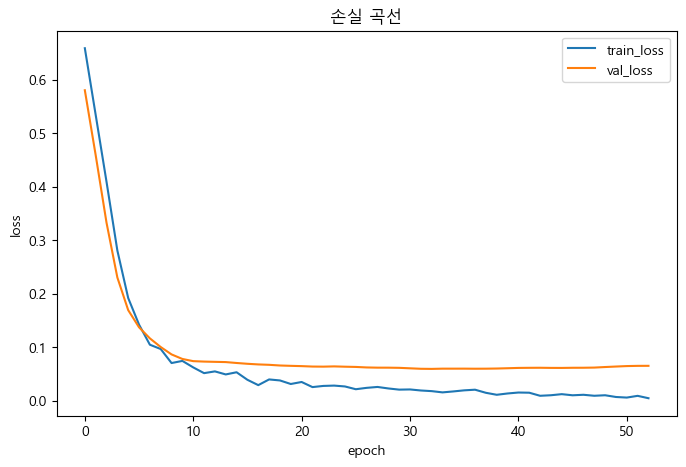

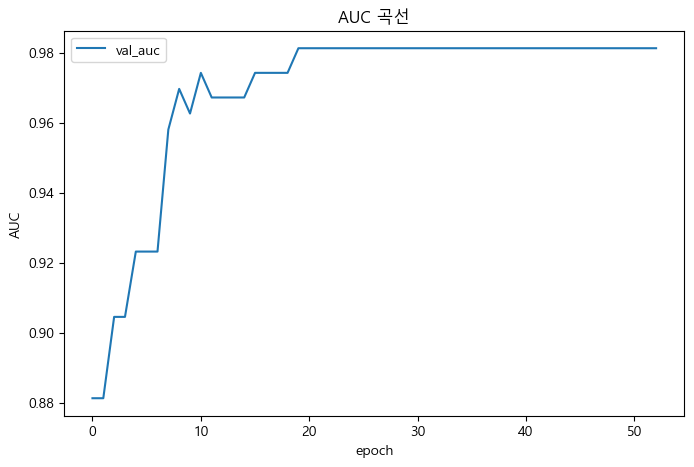

In [ ]:
plt.rcParams['font.family'] = "Malgun Gothic"       # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False          # 마이너스 깨짐 설정

# 학습 곡선 (Trial/Val Loss, Val AUC)
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'],label='train_loss')
plt.plot(history['val_loss'],label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('손실 곡선')
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history['val_auc'], label='val_auc')   # epoch별 검증 AUC값
plt.xlabel('epoch')
plt.ylabel('AUC')
plt.title('AUC 곡선')
plt.legend()
plt.show()


- 손실곡선 (Loss CUrve) : 과적합 여부 확인
    - 학습 손실과 검증 손실의 차이를 통해 모델이 학습 데이터를 과도하게 외우고 있는지 판단
    - 학습 손실 곡선은 계속 감소하면서, 검증 손실이 증가하면 과적합의 신호
- AUC 곡선 (AUC Curve) : 분류 성능의 개선 추이를 확인
    - 모델의 전반적인 분류 능력이 학습 과정에서 어떻게 변화하는지 확인
    - auc가 꾸준히 증가하면 클래스 간 구분 능력이 향상되고 있음을 의미
    - 정체되거나 하락하면 추가 학습이 성능 개선으로 이어지지 않음을 의미

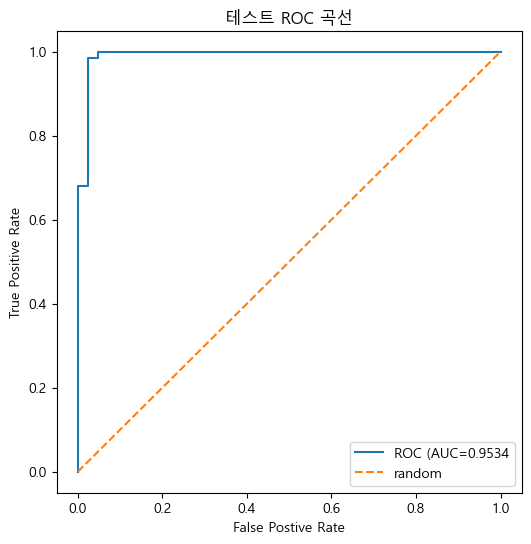

In [ ]:
# ROC 곡선
fpr, tpr, thr = roc_curve(y_true, y_prob)               # 실제값(y_true)와 예측 확률(y_prob)으로 ROC 곡선 좌표 계산

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC (AUC={test_auc:.4f}')
plt.plot([0,1],[0,1],linestyle="--",label="random")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('테스트 ROC 곡선')
plt.legend()
plt.show()

ROC 곡선 : 분류 임계값 변화에 따른 모델의 판별 성능을 시각적으로 평가하는 지표  
AUC가 클수록 성능에 좋다.  
분류 기준 임계깞을 0~1 사이에서 변화시키면서, 거짓 양성 비율(FPR)과 참 양성 비율(TPR)의 관계를 나타낸다.  
이 모델이 양성과 음성을 얼마나 잘 구분하는지를 확인할 수있다.  
AUC는 ROC 곡선 아래 면적으로, 무작위로 하나의 양성과 음성을 선택했을때 모델이 올바르게 순서를 매길 확률을 해석할 수 있다.

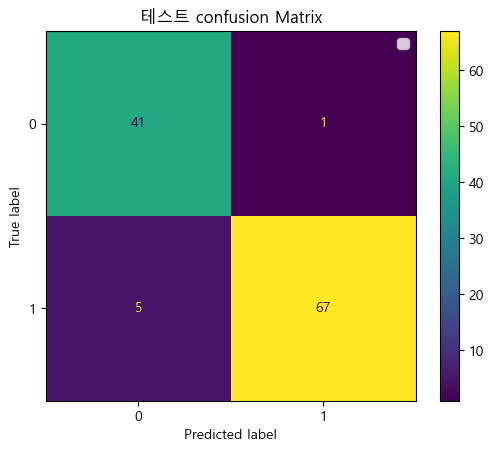

In [171]:
# 혼동행렬
y_pred = (y_prob > 0.5).astype(int)                     # 예측확률을 임계값 0.5 기준으로 이진 클래스 (0/1)로 변환
cm = confusion_matrix(y_true, y_pred)                   # 실제값과 예측값을 비교해 혼동행렬 계산
disp = ConfusionMatrixDisplay(confusion_matrix=cm)      # 혼동행렬 시각화 객체 생성
disp.plot()                                             # 혼동행렬 시각화
plt.title('테스트 confusion Matrix')
plt.legend()
plt.show()

- 혼동행렬은 각 클래스별로 얼마나 맞추고 틀렸는지를 숫자로 보여준다.
그래서 모델의 오류 유형을 분석하는데 용이한 면이 있다.

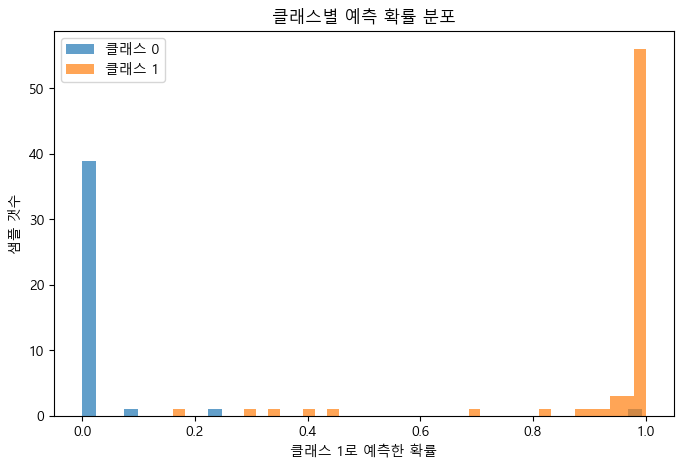

In [174]:
# 클래스별 예측 확률 분포
plt.figure(figsize=(8, 5))
plt.hist(
    y_prob[y_true == 0],        # 실제 클래스 0에 대한 예측 확률
    bins = 40,
    alpha = 0.7,                # 투명도 0.7
    label = '클래스 0'
)
plt.hist(
    y_prob[y_true == 1],         # 실제 클래스 1에 대한 예측 확률
    bins = 40,
    alpha = 0.7,
    label = '클래스 1'
)
plt.xlabel('클래스 1로 예측한 확률')
plt.ylabel('샘플 갯수')
plt.title('클래스별 예측 확률 분포')
plt.legend()

- 클래스별 예측 확률 분포는 모델이 두 클래스를 얼마나 명확하게 구분하고 있는지를 보여주는 시각화 자료이다.
    - x축 : 모델이 클래스 1일 확률이라고 예측한 값
    - 색상 : 파란색(실제 클래스 0), 주황색(실제 클래스 1)
    - 틀린예측 
        - 파란색에 있는 주황색 => 모델이 클래스 1을 클래스 0으로 판단 (False negative)
        - 주황색에 있는 파란색 => 모델이 클래스 0을 클래스 1로 판단 (False Positive)
    - 현재상태 : 나쁘진 않은 상태 (분류 경계는 명확, 모델의 확신도 높다. AUC가 높은 가능성이 크다)


### 분류모델에서 성능을 끌어올리기 위한 기법
1. 은닉층 변경
2. 하이퍼파라미터 최적화 (optuna)
3. 최적화 함수 변경 (Adam > AdamW, NAdam, RAdam)
4. 스케일러 변경 (StandardScaler -> MinMaxScaler, RobustScaler)
5. 클래스 불균형 해소 (SMOTE) : 데이터 증강

### 과적합 회피 기법

1. Dropout or BatchNorm
2. Scheduler : 점진적으로 lr 제어 (ReduceLROnPlatenu 등)
3. Early Stopping
4. K-Fold Cross Validation (K번 분할해서 평가 진행)